# Cell-Type-Aware Similarity: Building GEP Trees Across K Values

**Prerequisite:** Run `gsea_celltype_annotation.ipynb` first to generate NES CSVs.

**Problem:** Naive correlation of all GEPs at K with all GEPs at K+1 can conflate programs from different cell types, producing spurious cross-cell-type edges.

**Solution:** Choose one of two similarity metrics:
1. **`nes_spearman`** — Spearman correlation of NES profile vectors (GEP × cell type)
2. **`nes_kl_divergence`** — Similarity derived from symmetric KL divergence of cell-type probability distributions (mapped from KL ∈ [0, ∞) to similarity ∈ (0, 1] via exp(−λ · KL))

**Hierarchical family-aware labels (optional):** When a GEP's top cell type is not clearly dominant, the naive label is `Ambiguous/Mixed`. If you supply `CELLTYPE_FAMILIES` (a dict mapping families → list of cell types), the top-N cell types are inspected: if they all belong to the same family (e.g., all 3 are monocytes), the GEP is labeled with the family name (e.g., `Monocyte_family`) instead of `Ambiguous/Mixed`. Set `CELLTYPE_FAMILIES = None` to disable this behavior (original pipeline).

**Output:** An edge list defining the GEP tree across K values, plus visualizations.

In [1]:
import os
import glob
import re
import numpy as np
import networkx as nx
from collections import Counter
import pandas as pd
from scipy.stats import spearmanr
from scipy.special import rel_entr  # for KL divergence
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

## 1. Configuration

In [2]:
# ──────────────────────────────────
# Paths
# ──────────────────────────────────
GSEA_DIR = "combined-hnc_k3-35_gsea_celltype_results"        # Directory with NES_k*.csv files
OUTPUT_DIR = "combined-hnc_k3-35_corr-tree_kl-divergence"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ──────────────────────────────────
# K range
# ──────────────────────────────────
K_MIN = 3
K_MAX = 35

# ──────────────────────────────────
# Similarity metric (pick ONE)
# ──────────────────────────────────
# "nes_kl_divergence"  — Symmetric KL divergence mapped to similarity via exp(-λ·KL)
# "nes_spearman"       — Spearman correlation of NES profile vectors
SIMILARITY_METRIC = "nes_kl_divergence"

# ──────────────────────────────────
# KL divergence parameters (only used when SIMILARITY_METRIC == "nes_kl_divergence")
# ──────────────────────────────────
LAMBDA_KL = 0.5   # Controls steepness of the KL → similarity mapping:
                   #   exp(-λ·KL).  Larger λ = stricter (small KL differences already produce low similarity).
                   #   λ = 0.5 is a reasonable default
EPSILON = 1e-8     # Small constant to avoid log(0) in KL computation

# ──────────────────────────────────
# Edge selection
# ──────────────────────────────────
# For each child GEP at K+1, pick the best parent at K. A parent can have multiple children (splitting).
MIN_SIMILARITY = 0.3  # Minimum similarity to form an edge.
                       # For nes_spearman: Spearman rho threshold.
                       # For nes_kl_divergence: exp(-λ·KL) threshold --> converts the KL into a (0 to 1) range 

# ──────────────────────────────────
# Cell-type ambiguity detection
# ──────────────────────────────────
AMBIGUITY_THRESHOLD = 0.05  # If (1st_prob - 2nd_prob) / 1st_prob < this,
                             # label node as "Ambiguous/Mixed" instead of
                             # the top cell type.  Range [0, 1]:
                             #   0.0 = never ambiguous (always pick top)
                             #   1.0 = almost always ambiguous

# ──────────────────────────────────
# Hierarchical cell-type families (OPTIONAL)
# ──────────────────────────────────
# Map each family label → list of cell-type names (must match column names in the NES CSVs).
# When set, a GEP that would otherwise be labeled "Ambiguous/Mixed" is checked against
# these families: if its top `FAMILY_CHECK_TOP_N` cell types all belong to the same
# family, the GEP gets `"<family>" + FAMILY_LABEL_SUFFIX` (e.g., "Monocyte_family")
# instead of "Ambiguous/Mixed". This recovers biologically meaningful labels
# for mixtures of closely-related subtypes.
#
# Set CELLTYPE_FAMILIES = None to disable entirely (original behavior).
#
# The current definitions below match the HNC myeloid cell-type labels used in the
# NES CSVs. For a different dataset, either redefine this dict or set it to None.
CELLTYPE_FAMILIES = {
    "Monocyte":   ["Mono_CD14", "Mono_CD14_ID1", "Mono_CD14_IL1B", "Mono_CD14_THBS1",
                   "Mono_CD16", "Mono_Int", "Mono_TIL"],
    "DC":         ["cDC1_CLEC9A", "cDC2_CD1C", "cDC2_CD33", "DC_pDC", "mregDC_LAMP3"],
    "Macrophage": ["Mac_CXCL9", "Mac_IL1B", "Mac_IL1Bint", "Mac_SPP1"],
    "Mast":       ["Mast"],
}

FAMILY_CHECK_TOP_N = 3          # how many top cell types must share a family
                                # for a GEP to be labeled at the family level
                                # (ignored if CELLTYPE_FAMILIES is None)
FAMILY_LABEL_SUFFIX = "_family"  # final label = f"{family}{FAMILY_LABEL_SUFFIX}"

print(f"Similarity metric: {SIMILARITY_METRIC}")
if SIMILARITY_METRIC == "nes_kl_divergence":
    print(f"  Lambda (KL mapping): {LAMBDA_KL}")
    print(f"  Epsilon: {EPSILON}")
print(f"Min similarity threshold: {MIN_SIMILARITY}")
print(f"Ambiguity threshold: {AMBIGUITY_THRESHOLD}")
print(f"K range: {K_MIN}–{K_MAX}")

if CELLTYPE_FAMILIES is None:
    print("Hierarchical families: DISABLED (no family-level labels will be produced)")
else:
    print(f"Hierarchical families: ENABLED ({len(CELLTYPE_FAMILIES)} families)")
    for fam, cts in CELLTYPE_FAMILIES.items():
        print(f"  {fam}{FAMILY_LABEL_SUFFIX}: {len(cts)} cell types → {cts}")
    print(f"  Top-N check: top {FAMILY_CHECK_TOP_N} cell types must all be in the same family")

Similarity metric: nes_kl_divergence
  Lambda (KL mapping): 0.5
  Epsilon: 1e-08
Min similarity threshold: 0.3
Ambiguity threshold: 0.05
K range: 3–35
Hierarchical families: ENABLED (4 families)
  Monocyte_family: 7 cell types → ['Mono_CD14', 'Mono_CD14_ID1', 'Mono_CD14_IL1B', 'Mono_CD14_THBS1', 'Mono_CD16', 'Mono_Int', 'Mono_TIL']
  DC_family: 5 cell types → ['cDC1_CLEC9A', 'cDC2_CD1C', 'cDC2_CD33', 'DC_pDC', 'mregDC_LAMP3']
  Macrophage_family: 4 cell types → ['Mac_CXCL9', 'Mac_IL1B', 'Mac_IL1Bint', 'Mac_SPP1']
  Mast_family: 1 cell types → ['Mast']
  Top-N check: top 3 cell types must all be in the same family


## 2. Load NES Scores

In [3]:
all_nes = {}   # k -> DataFrame (GEPs × cell types)
k_values = []

for f in sorted(glob.glob(os.path.join(GSEA_DIR, "NES_k*.csv"))):
    match = re.search(r'NES_k(\d+)\.csv', os.path.basename(f))
    if match:
        k = int(match.group(1))
        if K_MIN <= k <= K_MAX:
            df = pd.read_csv(f, index_col=0)
            all_nes[k] = df
            k_values.append(k)

k_values = sorted(k_values)
print(f"Loaded NES for {len(k_values)} K values: {k_values}")
for k in k_values:
    print(f"  K={k}: {all_nes[k].shape[0]} GEPs × {all_nes[k].shape[1]} cell types")

Loaded NES for 33 K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
  K=3: 3 GEPs × 17 cell types
  K=4: 4 GEPs × 17 cell types
  K=5: 5 GEPs × 17 cell types
  K=6: 6 GEPs × 17 cell types
  K=7: 7 GEPs × 17 cell types
  K=8: 8 GEPs × 17 cell types
  K=9: 9 GEPs × 17 cell types
  K=10: 10 GEPs × 17 cell types
  K=11: 11 GEPs × 17 cell types
  K=12: 12 GEPs × 17 cell types
  K=13: 13 GEPs × 17 cell types
  K=14: 14 GEPs × 17 cell types
  K=15: 15 GEPs × 17 cell types
  K=16: 16 GEPs × 17 cell types
  K=17: 17 GEPs × 17 cell types
  K=18: 18 GEPs × 17 cell types
  K=19: 19 GEPs × 17 cell types
  K=20: 20 GEPs × 17 cell types
  K=21: 21 GEPs × 17 cell types
  K=22: 22 GEPs × 17 cell types
  K=23: 23 GEPs × 17 cell types
  K=24: 24 GEPs × 17 cell types
  K=25: 25 GEPs × 17 cell types
  K=26: 26 GEPs × 17 cell types
  K=27: 27 GEPs × 17 cell types
  K=28: 28 GEPs × 17 cell types
  K=29: 29 GEPs × 17 cell ty

## 3. Helper Functions

In [4]:
def nes_to_distribution(nes_row, epsilon=EPSILON):
    """
    Convert a NES score vector into a probability distribution
    for KL divergence computation.
    Applies ReLU (only positive enrichments contribute), then normalizes.
    If no positive values exist, returns a uniform distribution.
    """
    vals = np.maximum(nes_row.values.astype(float), 0.0)
    if vals.sum() == 0:
        return np.ones(len(vals)) / len(vals)
    dist = vals / vals.sum()
    dist = dist + epsilon
    dist = dist / dist.sum()
    return dist


def _build_ct_to_family(celltype_families):
    """
    Invert the family → [cell types] dict into a {cell type: family} lookup.
    Returns None if `celltype_families` is None. Cell types that appear in
    multiple families raise a ValueError (families should be disjoint).
    """
    if celltype_families is None:
        return None
    mapping = {}
    for fam, cts in celltype_families.items():
        for ct in cts:
            if ct in mapping and mapping[ct] != fam:
                raise ValueError(
                    f"Cell type '{ct}' appears in multiple families "
                    f"('{mapping[ct]}' and '{fam}'). Families must be disjoint."
                )
            mapping[ct] = fam
    return mapping


def is_family_label(label, family_label_suffix=FAMILY_LABEL_SUFFIX,
                    celltype_families=CELLTYPE_FAMILIES):
    """
    Return True if `label` is a family-level label produced by `assign_celltype`.
    (i.e., of the form "<family>" + FAMILY_LABEL_SUFFIX for a known family).
    Returns False when families are disabled.
    """
    if celltype_families is None or not label.endswith(family_label_suffix):
        return False
    family_name = label[:-len(family_label_suffix)] if family_label_suffix else label
    return family_name in celltype_families


def assign_celltype(nes_row,
                    epsilon=EPSILON,
                    ambiguity_threshold=AMBIGUITY_THRESHOLD,
                    celltype_families=CELLTYPE_FAMILIES,
                    family_check_top_n=FAMILY_CHECK_TOP_N,
                    family_label_suffix=FAMILY_LABEL_SUFFIX):
    """
    Assign a cell-type label to a GEP.

    Logic:
      1. Convert NES → probability distribution (ReLU → normalize).
      2. If the top cell type is dominant ((p1 - p2)/p1 ≥ ambiguity_threshold),
         return the top cell type.
      3. Otherwise (ambiguous) and `celltype_families` is provided:
         inspect the top `family_check_top_n` cell types. If all of them
         belong to the same family, return "<family>" + family_label_suffix
         (e.g., "Monocyte_family").
      4. If the family check fails or families are disabled, return "Ambiguous/Mixed".

    Parameters
    ----------
    nes_row : pd.Series
        NES scores indexed by cell type.
    epsilon : float
        Numerical-stability constant for the probability distribution.
    ambiguity_threshold : float
        Dominance cutoff in [0, 1]. If (p1 − p2)/p1 < this, treat as ambiguous.
    celltype_families : dict[str, list[str]] or None
        Family definitions. `None` disables family resolution entirely.
    family_check_top_n : int
        Number of top cell types that must share a family for a family-level
        label to be applied. Ignored when `celltype_families` is None.
    family_label_suffix : str
        Appended to the family name to form the label (e.g., "_family").

    Returns
    -------
    str
        One of:
          - a specific cell-type label (from `nes_row.index`)
          - a family label (e.g., "Monocyte_family")
          - "Ambiguous/Mixed"
    """
    dist = nes_to_distribution(nes_row, epsilon)
    dist_series = pd.Series(dist, index=nes_row.index)
    ranked = dist_series.sort_values(ascending=False)

    top1_ct = ranked.index[0]
    top1_prob = ranked.iloc[0]

    if len(ranked) < 2 or top1_prob == 0:
        return top1_ct

    top2_prob = ranked.iloc[1]
    dominance = (top1_prob - top2_prob) / top1_prob   # 1 = fully dominant

    if dominance >= ambiguity_threshold:
        return top1_ct

    # ─── Ambiguous. Try to resolve to a family label. ───
    if celltype_families is not None:
        ct_to_family = _build_ct_to_family(celltype_families)
        top_n = min(family_check_top_n, len(ranked))
        top_cts = list(ranked.index[:top_n])
        top_families = [ct_to_family.get(ct, None) for ct in top_cts]

        # All top-N must map to the SAME non-None family
        first_fam = top_families[0]
        if first_fam is not None and all(f == first_fam for f in top_families):
            return f"{first_fam}{family_label_suffix}"

    return "Ambiguous/Mixed"


def symmetric_kl(p, q):
    """
    Symmetric KL divergence: 0.5 * (KL(P||Q) + KL(Q||P)).
    Returns 0 when P == Q, increases without bound as distributions diverge.
    """
    return 0.5 * (np.sum(rel_entr(p, q)) + np.sum(rel_entr(q, p)))


def compute_similarity(nes_parent, nes_child,
                       metric="nes_spearman",
                       lambda_kl=LAMBDA_KL, epsilon=EPSILON):
    """
    Compute similarity between a parent GEP and a child GEP using the
    chosen metric. Uses the currently configured family settings when
    labeling parent/child cell types.
    """
    # Align cell types
    common_ct = nes_parent.index.intersection(nes_child.index)
    p_aligned = nes_parent[common_ct]
    c_aligned = nes_child[common_ct]

    parent_ct = assign_celltype(p_aligned)
    child_ct = assign_celltype(c_aligned)
    ct_match = (parent_ct == child_ct)

    if metric == "nes_spearman":
        if len(common_ct) < 3:
            sim = 0.0
            raw = 0.0
        else:
            rho, _ = spearmanr(p_aligned.values, c_aligned.values)
            rho = rho if not np.isnan(rho) else 0.0
            sim = rho
            raw = rho

    elif metric == "nes_kl_divergence":
        p_dist = nes_to_distribution(p_aligned, epsilon)
        c_dist = nes_to_distribution(c_aligned, epsilon)
        kl = symmetric_kl(p_dist, c_dist)
        sim = np.exp(-lambda_kl * kl)   # maps KL ∈ [0,∞) → sim ∈ (0, 1]
        raw = kl

    else:
        raise ValueError(f"Unknown metric: {metric}")

    return {
        'similarity': sim,
        'raw_value': raw,
        'parent_celltype': parent_ct,
        'child_celltype': child_ct,
        'celltype_match': ct_match
    }

## 4. Compute All Pairwise Similarities Across Consecutive K Values

In [5]:
# For each consecutive (K, K+1) pair, compute the full similarity matrix
# between all parent GEPs at K and all child GEPs at K+1.

all_sim_matrices = {}   # (k_parent, k_child) -> DataFrame
all_detail_records = [] # list of dicts for detailed inspection

for i in range(len(k_values) - 1):
    k_parent = k_values[i]
    k_child = k_values[i + 1]

    nes_p = all_nes[k_parent]
    nes_c = all_nes[k_child]

    sim_matrix = pd.DataFrame(
        index=nes_p.index,
        columns=nes_c.index,
        dtype=float
    )

    for parent_gep in nes_p.index:
        for child_gep in nes_c.index:
            result = compute_similarity(
                nes_parent=nes_p.loc[parent_gep],
                nes_child=nes_c.loc[child_gep],
                metric=SIMILARITY_METRIC,
                lambda_kl=LAMBDA_KL,
                epsilon=EPSILON
            )

            sim_matrix.loc[parent_gep, child_gep] = result['similarity']

            all_detail_records.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': parent_gep,
                'child_gep': child_gep,
                'similarity': result['similarity'],
                'raw_value': result['raw_value'],
                'parent_celltype': result['parent_celltype'],
                'child_celltype': result['child_celltype'],
                'celltype_match': result['celltype_match']
            })

    all_sim_matrices[(k_parent, k_child)] = sim_matrix

    print(f"K={k_parent} → K={k_child}: "
          f"{sim_matrix.shape[0]} parents × {sim_matrix.shape[1]} children, "
          f"max similarity = {sim_matrix.values.max():.3f}")

details_df = pd.DataFrame(all_detail_records)
print(f"\nTotal pairwise comparisons: {len(details_df)}")

K=3 → K=4: 3 parents × 4 children, max similarity = 0.999
K=4 → K=5: 4 parents × 5 children, max similarity = 1.000
K=5 → K=6: 5 parents × 6 children, max similarity = 1.000
K=6 → K=7: 6 parents × 7 children, max similarity = 1.000
K=7 → K=8: 7 parents × 8 children, max similarity = 1.000
K=8 → K=9: 8 parents × 9 children, max similarity = 1.000
K=9 → K=10: 9 parents × 10 children, max similarity = 1.000
K=10 → K=11: 10 parents × 11 children, max similarity = 1.000
K=11 → K=12: 11 parents × 12 children, max similarity = 1.000
K=12 → K=13: 12 parents × 13 children, max similarity = 1.000
K=13 → K=14: 13 parents × 14 children, max similarity = 1.000
K=14 → K=15: 14 parents × 15 children, max similarity = 1.000
K=15 → K=16: 15 parents × 16 children, max similarity = 1.000
K=16 → K=17: 16 parents × 17 children, max similarity = 1.000
K=17 → K=18: 17 parents × 18 children, max similarity = 1.000
K=18 → K=19: 18 parents × 19 children, max similarity = 1.000
K=19 → K=20: 19 parents × 20 child

## 5. Build the Edge List (Parent → Child Assignments)

**Strategy:** For each child GEP at K+1, assign the best parent at K (greedy best-match-per-child). A parent can have 0, 1, or many children (supporting splits). Children with no parent above `MIN_SIMILARITY` are flagged as "novel" (de novo emergence).

In [6]:
edges = []

for (k_parent, k_child), sim_matrix in sorted(all_sim_matrices.items()):
    for child_gep in sim_matrix.columns:
        best_parent = sim_matrix[child_gep].idxmax()
        best_sim = sim_matrix[child_gep].max()

        if best_sim >= MIN_SIMILARITY:
            parent_ct = assign_celltype(all_nes[k_parent].loc[best_parent])
            child_ct = assign_celltype(all_nes[k_child].loc[child_gep])

            edges.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': best_parent,
                'child_gep': child_gep,
                'similarity': round(best_sim, 4),
                'parent_celltype': parent_ct,
                'child_celltype': child_ct,
                'celltype_match': parent_ct == child_ct
            })
        else:
            child_ct = assign_celltype(all_nes[k_child].loc[child_gep])
            edges.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': None,
                'child_gep': child_gep,
                'similarity': round(best_sim, 4),
                'parent_celltype': None,
                'child_celltype': child_ct,
                'celltype_match': False
            })

edges_df = pd.DataFrame(edges)

n_connected = edges_df['parent_gep'].notna().sum()
n_novel = edges_df['parent_gep'].isna().sum()
n_ct_match = edges_df.loc[edges_df['parent_gep'].notna(), 'celltype_match'].sum()

print(f"Total edges: {len(edges_df)}")
print(f"  Connected (parent assigned): {n_connected}")
print(f"  Novel (no parent above threshold): {n_novel}")
print(f"  Cell-type-matching edges: {n_ct_match}/{n_connected} "
      f"({100*n_ct_match/max(n_connected,1):.1f}%)")

edges_path = os.path.join(OUTPUT_DIR, "gep_tree_edges.csv")
edges_df.to_csv(edges_path, index=False)
print(f"\nEdge list saved to: {edges_path}")
edges_df.head(10)

Total edges: 624
  Connected (parent assigned): 610
  Novel (no parent above threshold): 14
  Cell-type-matching edges: 378/610 (62.0%)

Edge list saved to: combined-hnc_k3-35_corr-tree_kl-divergence/gep_tree_edges.csv


,k_parent,k_child,parent_gep,child_gep,similarity,parent_celltype,child_celltype,celltype_match
0,3,4,1.0,1,0.9970,Ambiguous/Mixed,Mono_CD14_ID1,False
1,3,4,2.0,2,0.9968,Mac_CXCL9,Ambiguous/Mixed,False
2,3,4,3.0,3,0.9990,DC_pDC,DC_pDC,True
3,3,4,3.0,4,0.9760,DC_pDC,Mac_IL1B,False
4,4,5,1.0,1,1.0000,Mono_CD14_ID1,Mono_CD14_ID1,True
5,4,5,2.0,2,0.9960,Ambiguous/Mixed,Ambiguous/Mixed,True
6,4,5,3.0,3,0.9998,DC_pDC,DC_pDC,True
7,4,5,4.0,4,1.0000,Mac_IL1B,Mac_IL1B,True
8,4,5,3.0,5,0.9896,DC_pDC,Mast,False
9,5,6,1.0,1,0.9974,Mono_CD14_ID1,Mono_CD14_ID1,True


## 6. Identify Splits and Merges

- **Split:** A parent at K maps to 2+ children at K+1
- **Merge:** A child at K+1 is the best match for 2+ parents at K (rare with best-match-per-child, but detectable)

In [7]:
connected_edges = edges_df[edges_df['parent_gep'].notna()].copy()

# Splits: parents with multiple children
splits = connected_edges.groupby(['k_parent', 'parent_gep']).agg(
    n_children=('child_gep', 'count'),
    children=('child_gep', list),
    child_celltypes=('child_celltype', list)
).reset_index()
splits = splits[splits['n_children'] > 1].sort_values('n_children', ascending=False)

print(f"Splitting events (parent with 2+ children):")
print(f"{'='*70}")
if len(splits) == 0:
    print("  None detected.")
else:
    for _, row in splits.iterrows():
        parent_ct = assign_celltype(all_nes[row['k_parent']].loc[row['parent_gep']])
        child_cts = row['child_celltypes']
        same_ct = all(ct == parent_ct for ct in child_cts)
        tag = "same cell type" if same_ct else "CROSS cell type"
        print(f"  K={row['k_parent']} {row['parent_gep']} ({parent_ct}) → "
              f"{row['n_children']} children: {row['children']} [{tag}]")
        for child, ct in zip(row['children'], child_cts):
            print(f"    └─ {child} ({ct})")

# Novel programs
novel = edges_df[edges_df['parent_gep'].isna()]
print(f"\nNovel programs (no parent above threshold):")
print(f"{'='*70}")
if len(novel) == 0:
    print("  None.")
else:
    for _, row in novel.iterrows():
        print(f"  K={row['k_child']} {row['child_gep']} ({row['child_celltype']}) "
              f"— best sim was {row['similarity']:.3f}")

Splitting events (parent with 2+ children):
  K=23 22.0 (Ambiguous/Mixed) → 9 children: [14, 15, 16, 17, 19, 20, 21, 23, 24] [CROSS cell type]
    └─ 14 (Ambiguous/Mixed)
    └─ 15 (cDC2_CD1C)
    └─ 16 (Mac_SPP1)
    └─ 17 (Ambiguous/Mixed)
    └─ 19 (DC_family)
    └─ 20 (DC_family)
    └─ 21 (Ambiguous/Mixed)
    └─ 23 (Macrophage_family)
    └─ 24 (Ambiguous/Mixed)
  K=19 9.0 (cDC2_CD1C) → 7 children: [5, 6, 7, 9, 10, 11, 12] [CROSS cell type]
    └─ 5 (Mac_IL1B)
    └─ 6 (Ambiguous/Mixed)
    └─ 7 (DC_family)
    └─ 9 (Mac_SPP1)
    └─ 10 (Mono_TIL)
    └─ 11 (mregDC_LAMP3)
    └─ 12 (Ambiguous/Mixed)
  K=28 10.0 (Ambiguous/Mixed) → 6 children: [8, 10, 13, 17, 19, 27] [CROSS cell type]
    └─ 8 (DC_family)
    └─ 10 (Ambiguous/Mixed)
    └─ 13 (Ambiguous/Mixed)
    └─ 17 (Ambiguous/Mixed)
    └─ 19 (Ambiguous/Mixed)
    └─ 27 (Ambiguous/Mixed)
  K=25 17.0 (Ambiguous/Mixed) → 6 children: [4, 9, 10, 11, 23, 24] [CROSS cell type]
    └─ 4 (DC_family)
    └─ 9 (Ambiguous/Mixed)
    └─

## 7. Visualizations

### 7a. Heatmaps: Similarity Matrices per K→K+1 Transition

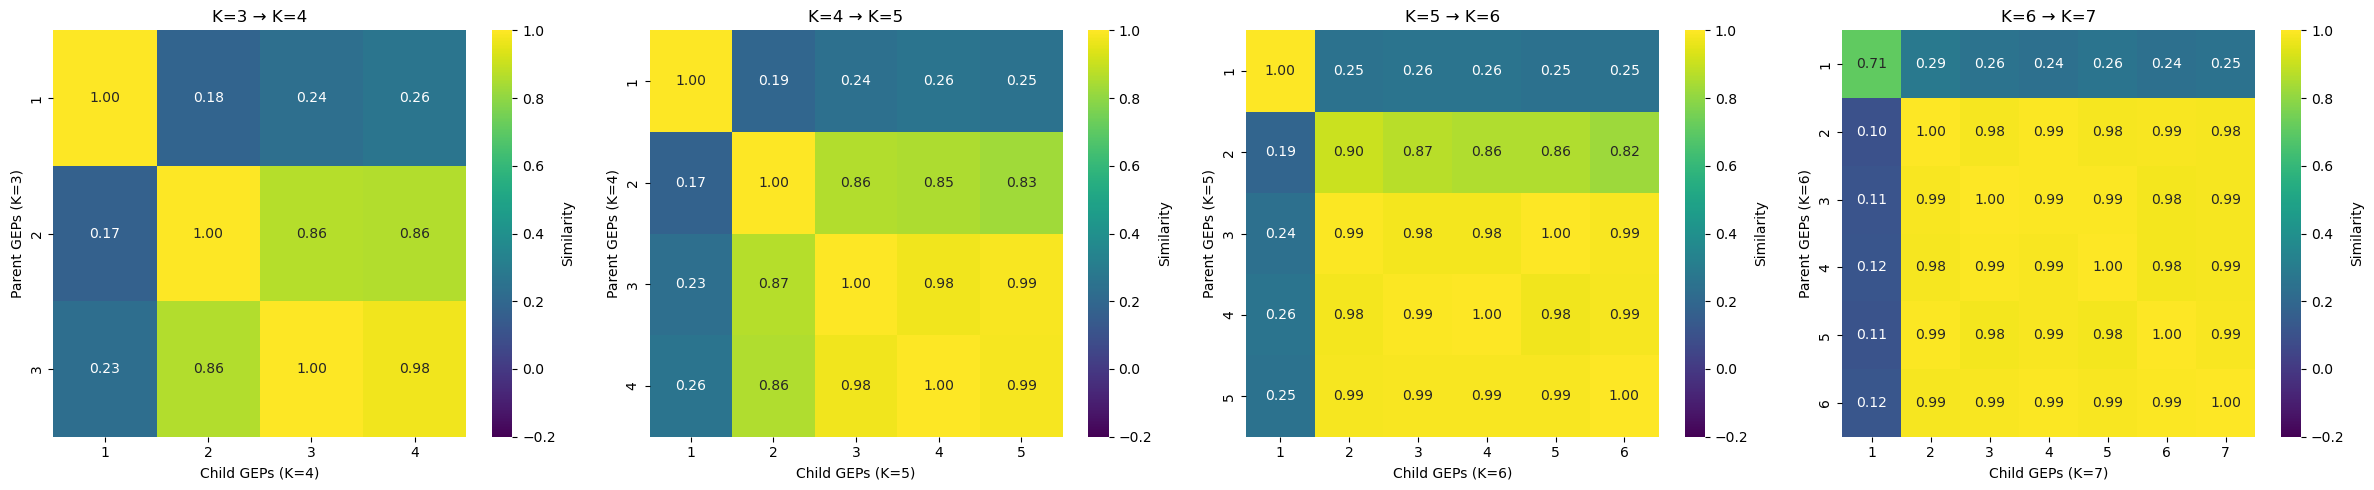

In [8]:
transitions_to_plot = list(all_sim_matrices.keys())[:4]

fig, axes = plt.subplots(1, len(transitions_to_plot),
                         figsize=(6 * len(transitions_to_plot), 5))
if len(transitions_to_plot) == 1:
    axes = [axes]

for ax, (k_p, k_c) in zip(axes, transitions_to_plot):
    sim = all_sim_matrices[(k_p, k_c)].astype(float)
    sns.heatmap(sim, cmap='viridis', annot=sim.shape[0] <= 12,
                fmt='.2f' if sim.shape[0] <= 12 else '',
                ax=ax, vmin=-0.2, vmax=1.0,
                cbar_kws={'label': 'Similarity'})
    ax.set_title(f'K={k_p} → K={k_c}', fontsize=12)
    ax.set_xlabel(f'Child GEPs (K={k_c})')
    ax.set_ylabel(f'Parent GEPs (K={k_p})')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "similarity_heatmaps.png"), dpi=150, bbox_inches='tight')
plt.show()

### 7b. GEP Tree Diagram

A layered graph showing GEPs at each K level connected by parent→child edges. Nodes are colored by their top cell type.

In [9]:
# Collect every label that appears in the tree, then split into three groups:
#   • specific cell types → tab20 palette
#   • family labels      → Set1 palette (distinct, saturated)
#   • "Ambiguous/Mixed"  → neutral gray
# This keeps the original behavior when CELLTYPE_FAMILIES is None (no family
# labels will be produced, so the family palette is simply empty).

all_labels = set()
for k in k_values:
    for gep in all_nes[k].index:
        all_labels.add(assign_celltype(all_nes[k].loc[gep]))

family_labels = sorted([l for l in all_labels if is_family_label(l)])
specific_cts  = sorted([l for l in all_labels
                        if l != 'Ambiguous/Mixed' and not is_family_label(l)])

# Specific cell types → tab20
cmap_ct = plt.cm.get_cmap('tab20', max(len(specific_cts), 1))
ct_colors = {ct: cmap_ct(i) for i, ct in enumerate(specific_cts)}

# Family labels → Set1 (distinct from tab20)
if family_labels:
    cmap_fam = plt.cm.get_cmap('Set1', max(len(family_labels), 3))
    for i, fam in enumerate(family_labels):
        ct_colors[fam] = cmap_fam(i)

# Ambiguous → neutral gray
if 'Ambiguous/Mixed' in all_labels:
    ct_colors['Ambiguous/Mixed'] = '#888888'

# Order for legend: specific cts first, then family labels, then ambiguous
all_celltypes = specific_cts + family_labels
if 'Ambiguous/Mixed' in all_labels:
    all_celltypes = all_celltypes + ['Ambiguous/Mixed']

print(f"Labels in tree: {len(all_celltypes)}")
print(f"  Specific cell types: {len(specific_cts)}")
for ct in specific_cts:
    print(f"    {ct}")
if family_labels:
    print(f"  Family labels:       {len(family_labels)}")
    for fl in family_labels:
        print(f"    {fl}")
if 'Ambiguous/Mixed' in all_labels:
    print(f"  Ambiguous/Mixed:     present")

Labels in tree: 17
  Specific cell types: 13
    DC_pDC
    Mac_CXCL9
    Mac_IL1B
    Mac_SPP1
    Mast
    Mono_CD14_ID1
    Mono_CD14_THBS1
    Mono_CD16
    Mono_TIL
    cDC1_CLEC9A
    cDC2_CD1C
    cDC2_CD33
    mregDC_LAMP3
  Family labels:       3
    DC_family
    Macrophage_family
    Monocyte_family
  Ambiguous/Mixed:     present


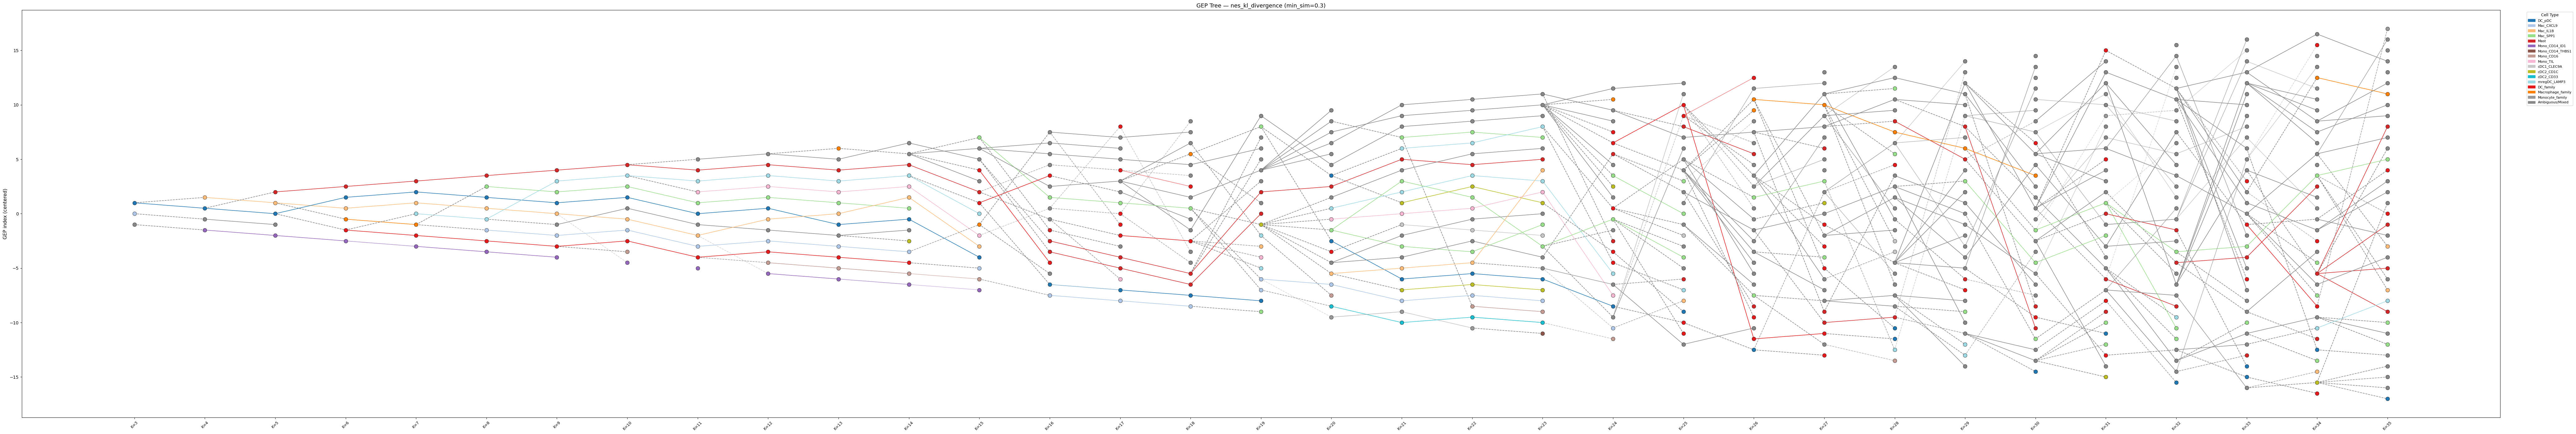

In [10]:
fig, ax = plt.subplots(figsize=(max(20, len(k_values) * 2.5), max(10, max(k_values) * 0.4)))

node_pos = {}
node_ct = {}

for xi, k in enumerate(k_values):
    n_geps = len(all_nes[k])
    for yi, gep in enumerate(all_nes[k].index):
        y = yi - (n_geps - 1) / 2
        node_pos[(k, gep)] = (xi, y)
        node_ct[(k, gep)] = assign_celltype(all_nes[k].loc[gep])

# Draw edges
connected = edges_df[edges_df['parent_gep'].notna()]
for _, row in connected.iterrows():
    p_key = (row['k_parent'], row['parent_gep'])
    c_key = (row['k_child'], row['child_gep'])
    if p_key in node_pos and c_key in node_pos:
        px, py = node_pos[p_key]
        cx, cy = node_pos[c_key]
        alpha = min(1.0, max(0.15, row['similarity']))
        color = 'gray' if not row['celltype_match'] else ct_colors.get(row['parent_celltype'], 'gray')
        ls = '-' if row['celltype_match'] else '--'
        ax.plot([px, cx], [py, cy], color=color, alpha=alpha, lw=1.2, ls=ls, zorder=1)

# Draw nodes
for (k, gep), (x, y) in node_pos.items():
    ct = node_ct[(k, gep)]
    color = ct_colors.get(ct, 'gray')
    ax.scatter(x, y, c=[color], s=80, edgecolors='black', linewidths=0.5, zorder=2)

ax.set_xticks(range(len(k_values)))
ax.set_xticklabels([f'K={k}' for k in k_values], fontsize=9, rotation=45)
ax.set_ylabel('GEP index (centered)', fontsize=11)
ax.set_title(f'GEP Tree — {SIMILARITY_METRIC} (min_sim={MIN_SIMILARITY})', fontsize=13)

patches = [mpatches.Patch(color=ct_colors[ct], label=ct) for ct in all_celltypes]
ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.01, 1.0),
          fontsize=8, title='Cell Type', title_fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gep_tree_diagram.png"), dpi=150, bbox_inches='tight')
plt.show()

### 7c. Cell Type Composition Across K Values

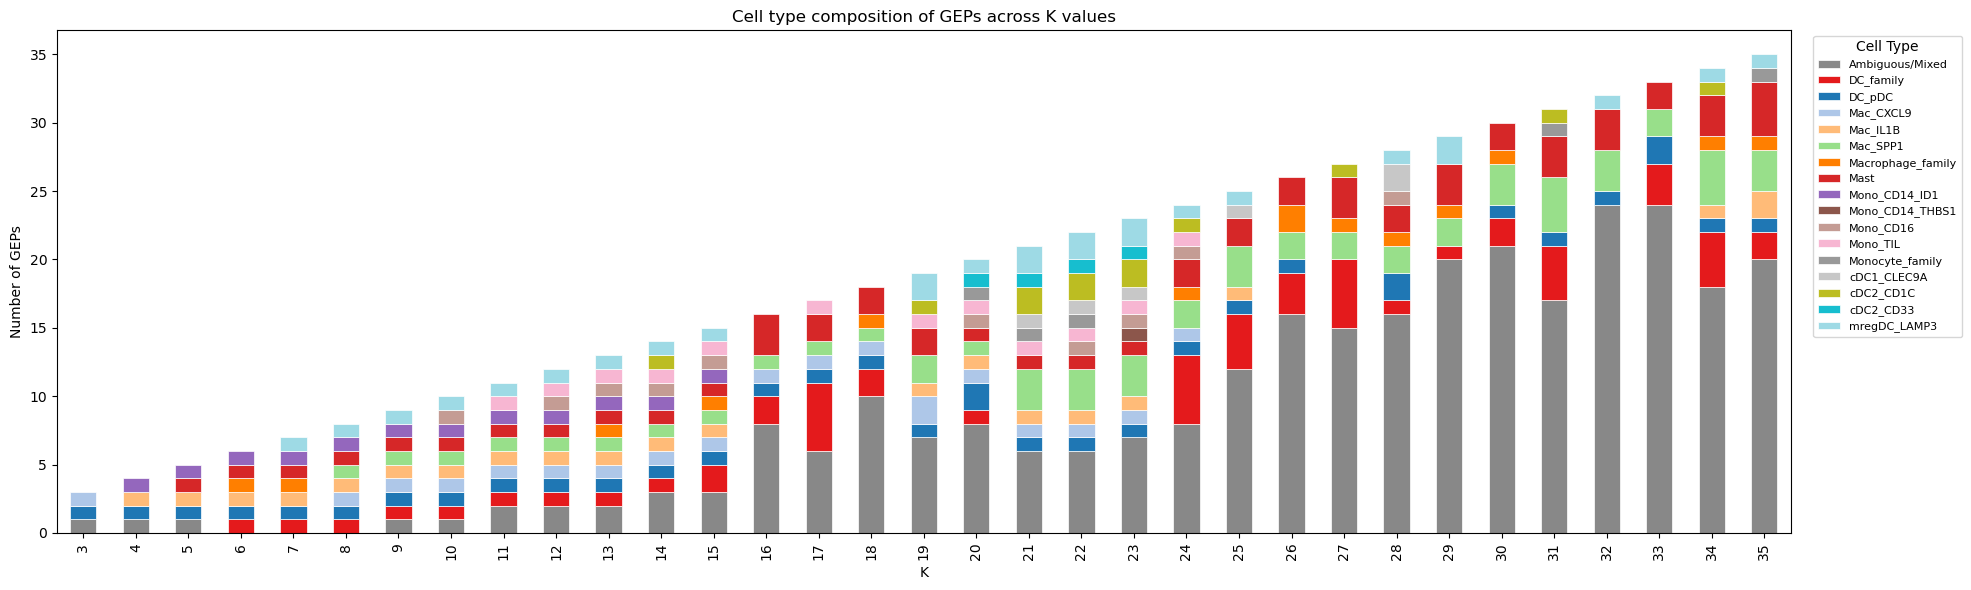

In [11]:
composition = []
for k in k_values:
    for gep in all_nes[k].index:
        ct = assign_celltype(all_nes[k].loc[gep])
        composition.append({'K': k, 'CellType': ct})

comp_df = pd.DataFrame(composition)
comp_pivot = comp_df.groupby(['K', 'CellType']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(max(10, len(k_values) * 0.6), 6))
comp_pivot.plot(kind='bar', stacked=True, ax=ax,
                color=[ct_colors.get(ct, 'gray') for ct in comp_pivot.columns],
                edgecolor='white', linewidth=0.5)
ax.set_xlabel('K')
ax.set_ylabel('Number of GEPs')
ax.set_title('Cell type composition of GEPs across K values')
ax.legend(bbox_to_anchor=(1.01, 1.0), fontsize=8, title='Cell Type')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "celltype_composition_by_k.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Pairwise Results

In [12]:
details_path = os.path.join(OUTPUT_DIR, "pairwise_similarities.csv")
details_df.to_csv(details_path, index=False)
print(f"Saved detailed pairwise similarities: {details_path}")
print(f"Shape: {details_df.shape}")
details_df.head()

Saved detailed pairwise similarities: combined-hnc_k3-35_corr-tree_kl-divergence/pairwise_similarities.csv
Shape: (14272, 9)


,k_parent,k_child,parent_gep,child_gep,similarity,raw_value,parent_celltype,child_celltype,celltype_match
0,3,4,1,1,0.996984,0.006040,Ambiguous/Mixed,Mono_CD14_ID1,False
1,3,4,1,2,0.180342,3.425801,Ambiguous/Mixed,Ambiguous/Mixed,True
2,3,4,1,3,0.235933,2.888417,Ambiguous/Mixed,DC_pDC,False
3,3,4,1,4,0.264084,2.662976,Ambiguous/Mixed,Mac_IL1B,False
4,3,4,2,1,0.167351,3.575321,Mac_CXCL9,Mono_CD14_ID1,False


In [13]:
for (k_p, k_c), sim_mat in all_sim_matrices.items():
    path = os.path.join(OUTPUT_DIR, f"sim_matrix_k{k_p}_to_k{k_c}.csv")
    sim_mat.to_csv(path)

print(f"Saved {len(all_sim_matrices)} similarity matrices to {OUTPUT_DIR}/")

Saved 32 similarity matrices to combined-hnc_k3-35_corr-tree_kl-divergence/


## 9. Per-Transition Summary Table

In [14]:
transition_summary = []

for (k_p, k_c) in sorted(all_sim_matrices.keys()):
    subset = edges_df[(edges_df['k_parent'] == k_p) & (edges_df['k_child'] == k_c)]
    connected = subset[subset['parent_gep'].notna()]
    novel = subset[subset['parent_gep'].isna()]

    if len(connected) > 0:
        parent_counts = connected['parent_gep'].value_counts()
        n_splits = (parent_counts > 1).sum()
    else:
        n_splits = 0

    transition_summary.append({
        'transition': f'K={k_p}→{k_c}',
        'n_parents': len(all_nes[k_p]),
        'n_children': len(all_nes[k_c]),
        'n_edges': len(connected),
        'n_novel': len(novel),
        'n_splits': n_splits,
        'pct_same_ct': f"{100 * connected['celltype_match'].mean():.0f}%" if len(connected) > 0 else 'N/A',
        'mean_sim': f"{connected['similarity'].mean():.3f}" if len(connected) > 0 else 'N/A'
    })

tsummary_df = pd.DataFrame(transition_summary)
tsummary_df.to_csv(os.path.join(OUTPUT_DIR, "transition_summary.csv"), index=False)
print(tsummary_df.to_string(index=False))

transition  n_parents  n_children  n_edges  n_novel  n_splits pct_same_ct mean_sim
     K=3→4          3           4        4        0         1         25%    0.992
     K=4→5          4           5        5        0         1         80%    0.997
     K=5→6          5           6        6        0         2         67%    0.997
     K=6→7          6           7        7        0         1         86%    0.957
     K=7→8          7           8        8        0         1         75%    0.999
     K=8→9          8           9        9        0         1         89%    1.000
    K=9→10          9          10       10        0         2         80%    0.929
   K=10→11         10          11       10        1         2         80%    0.999
   K=11→12         11          12       12        0         2         83%    0.927
   K=12→13         12          13       13        0         1         92%    1.000
   K=13→14         13          14       14        0         1         86%    0.980
   K

## 10. GEP NES Score Distributions at a Sample K

For each GEP node at a chosen K, plot the full NES score profile across all cell types.
The assigned cell type (from `assign_celltype`) is highlighted; all others are shown in gray.
The second row of each panel shows the derived probability distribution used for KL gating.

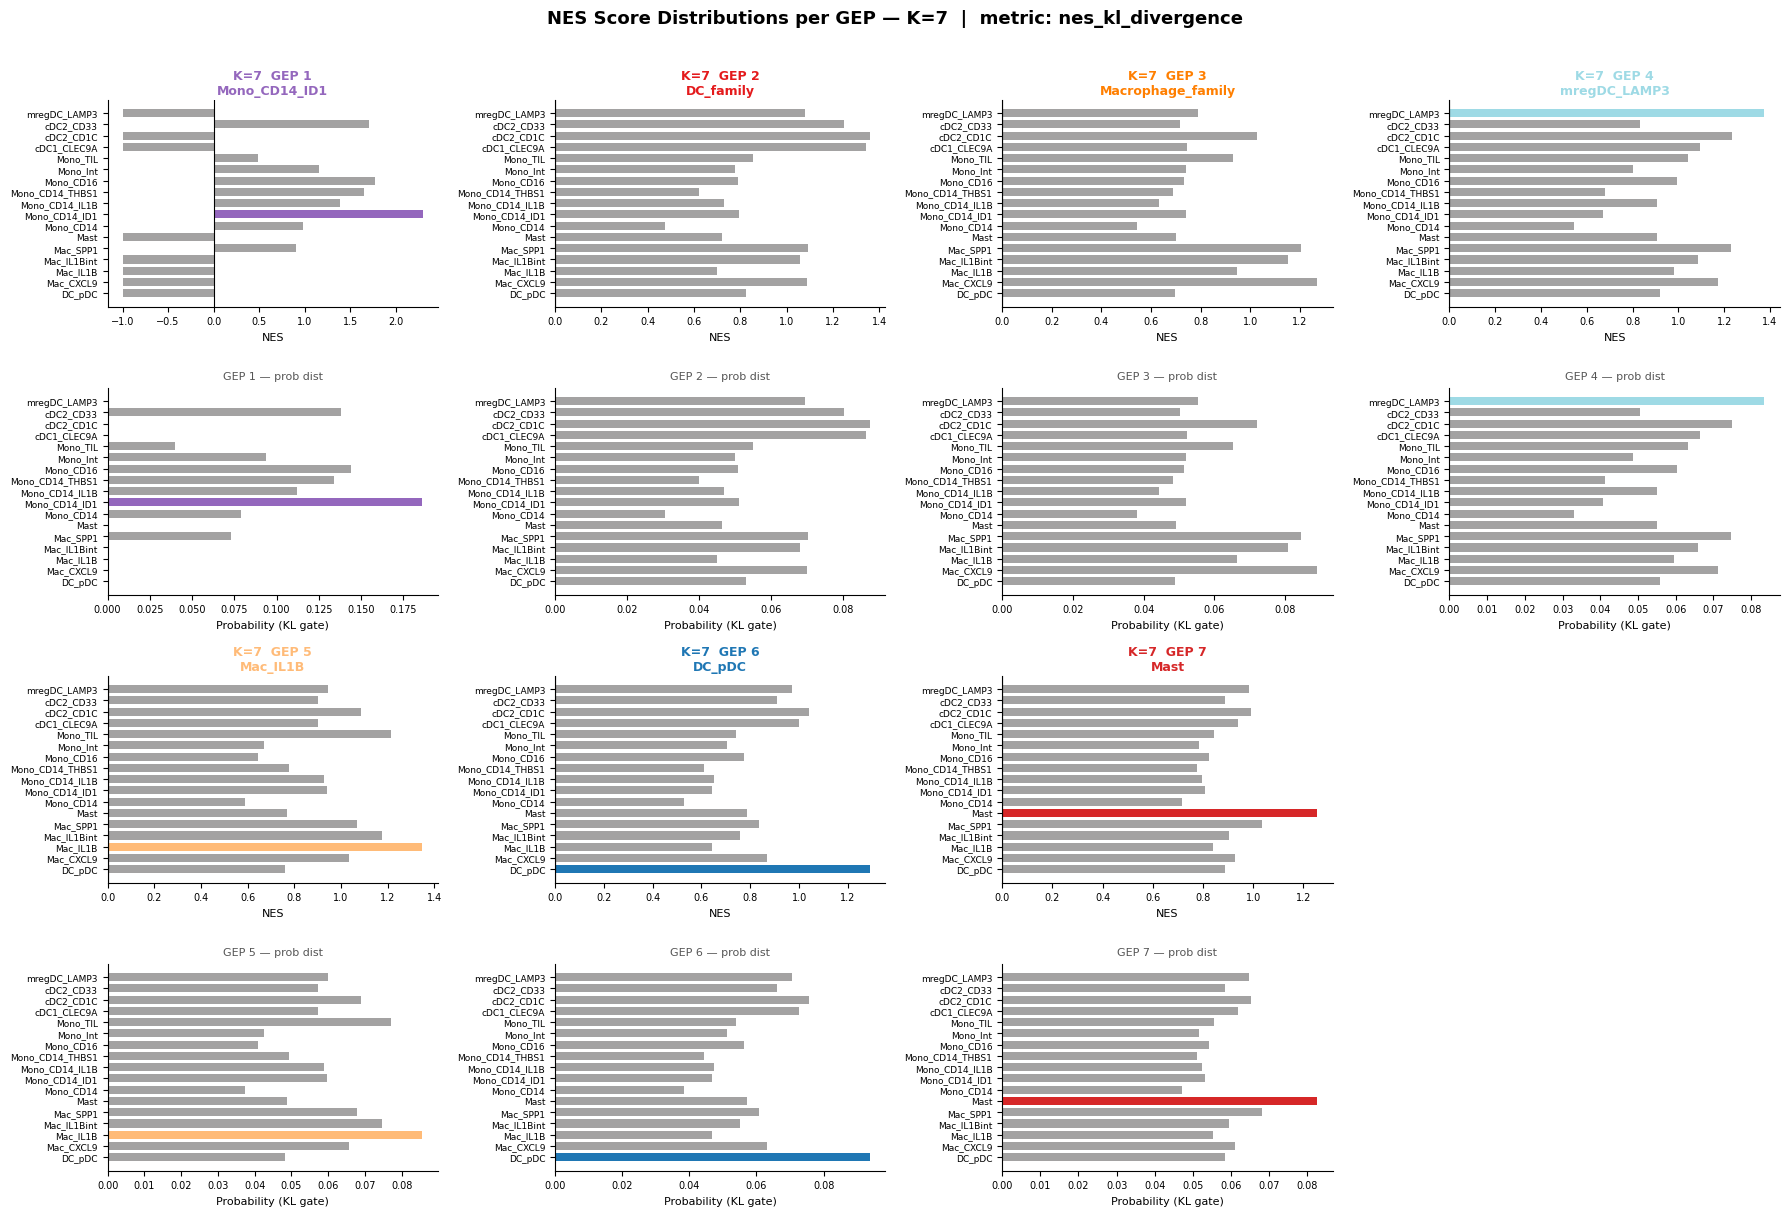

Saved → combined-hnc_k3-35_corr-tree_kl-divergence/nes_score_dist_k7.png


In [15]:
K_VIZ = 7
SHOW_PROB_DIST = True      # Set False to show only NES bars (no probability row)

nes_k = all_nes[K_VIZ]
n_geps = len(nes_k)
cell_types = nes_k.columns.tolist()

n_cols = min(4, n_geps)
n_rows_geps = int(np.ceil(n_geps / n_cols))
panel_rows = 2 if SHOW_PROB_DIST else 1   # NES row + optional prob-dist row

fig, axes = plt.subplots(
    n_rows_geps * panel_rows, n_cols,
    figsize=(n_cols * 4.5, n_rows_geps * panel_rows * 3.0),
    squeeze=False
)

for idx, gep in enumerate(nes_k.index):
    row_block = (idx // n_cols) * panel_rows   # first row of this GEP's block
    col       = idx % n_cols

    nes_row   = nes_k.loc[gep]
    ct_label  = assign_celltype(nes_row)
    prob_dist = nes_to_distribution(nes_row)   # ReLU-normalized, for KL gating
    node_color = ct_colors.get(ct_label, '#888888')

    # ── Bar colors: highlight the assigned cell type, gray out the rest ──
    bar_colors = [
        node_color if ct == ct_label else "#a3a2a2"
        for ct in cell_types
    ]
    y_pos = range(len(cell_types))

    # ── Top panel: raw NES scores ────────────────────────────────────────
    ax_nes = axes[row_block][col]
    ax_nes.barh(y_pos, nes_row.values, color=bar_colors, edgecolor='none', height=0.72)
    ax_nes.axvline(0, color='black', lw=0.8)
    ax_nes.set_yticks(y_pos)
    ax_nes.set_yticklabels(cell_types, fontsize=6.5)
    ax_nes.set_xlabel('NES', fontsize=8)
    ax_nes.set_title(
        f'K={K_VIZ}  GEP {gep}\n{ct_label}',
        fontsize=9, color=node_color, fontweight='bold', pad=4
    )
    ax_nes.tick_params(axis='x', labelsize=7)
    ax_nes.spines[['top', 'right']].set_visible(False)

    # ── Bottom panel: probability distribution used for KL gating ────────
    if SHOW_PROB_DIST:
        ax_prob = axes[row_block + 1][col]
        ax_prob.barh(y_pos, prob_dist, color=bar_colors, edgecolor='none', height=0.72)
        ax_prob.set_yticks(y_pos)
        ax_prob.set_yticklabels(cell_types, fontsize=6.5)
        ax_prob.set_xlabel('Probability (KL gate)', fontsize=8)
        ax_prob.set_title(f'GEP {gep} — prob dist', fontsize=8, color='#555555')
        ax_prob.tick_params(axis='x', labelsize=7)
        ax_prob.spines[['top', 'right']].set_visible(False)

# ── Hide any unused subplot slots ─────────────────────────────────────────
for idx in range(n_geps, n_rows_geps * n_cols):
    row_block = (idx // n_cols) * panel_rows
    col = idx % n_cols
    for pr in range(panel_rows):
        axes[row_block + pr][col].set_visible(False)

plt.suptitle(
    f'NES Score Distributions per GEP — K={K_VIZ}  |  metric: {SIMILARITY_METRIC}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, f'nes_score_dist_k{K_VIZ}.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

## 11. Landscape Statistics Across K

The tree built above is a multi-resolution object. The cells below describe how the
program landscape decomposes as K grows, **without prescribing any single K**:

- **11.1 Program persistence** — how many consecutive K each lineage survives
- **11.2 Emergence order** — the smallest K at which each cell type appears as a top assignment
- **11.3 Ambiguity & program-per-celltype trajectories** — landscape decomposition curves

### 11.1 Program Persistence via Connected Components

A **lineage** is a weakly connected component in the GEP tree (nodes linked by
parent → child edges across K). Two statistics per lineage:

- `k_span` = `k_max − k_min + 1` (total K range the lineage touches)
- `consecutive_span` = length of the longest CONTIGUOUS K-run inside the lineage

`consecutive_span` is the stricter statistic — a lineage that disappears for one K
and reappears has a large `k_span` but its `consecutive_span` is split. We use
`consecutive_span` as the primary persistence score.

Interpretation:
- High persistence → robust program, identifiable across many resolutions
- Persistence = 1–2 → resolution-specific; may be an artifact of a particular K
- High-persistence lineages concentrated in one cell type → that cell type has a
  stable, well-defined program; diffuse lineages suggest transient/shared programs

In [16]:
# ── Build the directed tree graph ─────────────────────────────────
G = nx.DiGraph()
for k in k_values:
    for gep in all_nes[k].index:
        ct = assign_celltype(all_nes[k].loc[gep])
        G.add_node((k, gep), k=k, gep=gep, celltype=ct)

connected_edges_only = edges_df[edges_df['parent_gep'].notna()]
for _, row in connected_edges_only.iterrows():
    G.add_edge(
        (row['k_parent'], row['parent_gep']),
        (row['k_child'],  row['child_gep']),
        similarity=row['similarity']
    )

def longest_consecutive_run(ks_sorted):
    """Length of the largest contiguous integer run in a sorted list."""
    if not ks_sorted:
        return 0
    longest = current = 1
    for i in range(1, len(ks_sorted)):
        if ks_sorted[i] == ks_sorted[i-1] + 1:
            current += 1
            longest = max(longest, current)
        else:
            current = 1
    return longest

# ── Weakly connected components = lineages ───────────────────────
wcc = list(nx.weakly_connected_components(G))

per_lineage_records = []
per_gep_records = []
for lid, nodes in enumerate(wcc):
    ks_unique  = sorted(set(n[0] for n in nodes))
    k_span     = max(ks_unique) - min(ks_unique) + 1
    consec_span = longest_consecutive_run(ks_unique)
    cts = [G.nodes[n]['celltype'] for n in nodes]
    ct_counts = Counter(cts)
    dom_ct, dom_ct_n = ct_counts.most_common(1)[0]

    per_lineage_records.append({
        'lineage_id': lid,
        'n_nodes': len(nodes),
        'k_min': min(ks_unique),
        'k_max': max(ks_unique),
        'k_span': k_span,
        'consecutive_span': consec_span,
        'dominant_celltype': dom_ct,
        'celltype_purity': round(dom_ct_n / len(nodes), 3),
    })
    for n in nodes:
        per_gep_records.append({
            'k': n[0],
            'gep': n[1],
            'celltype': G.nodes[n]['celltype'],
            'lineage_id': lid,
            'lineage_k_span': k_span,
            'lineage_consecutive_span': consec_span,
            'lineage_size': len(nodes),
            'lineage_dominant_celltype': dom_ct,
        })

lineage_df = pd.DataFrame(per_lineage_records).sort_values(
    'consecutive_span', ascending=False).reset_index(drop=True)
gep_persistence_df = pd.DataFrame(per_gep_records)

lineage_df.to_csv(os.path.join(OUTPUT_DIR, 'lineage_persistence.csv'), index=False)
gep_persistence_df.to_csv(os.path.join(OUTPUT_DIR, 'gep_persistence.csv'), index=False)

print(f"Total lineages (weakly connected components): {len(lineage_df)}")
print(f"\nLineage persistence summary (consecutive K span):")
print(lineage_df['consecutive_span'].describe().round(2))
print(f"\nTop 15 most persistent lineages:")
print(lineage_df.head(15).to_string(index=False))


Total lineages (weakly connected components): 17

Lineage persistence summary (consecutive K span):
count    17.00
mean      3.76
std       7.71
min       1.00
25%       1.00
50%       1.00
75%       3.00
max      33.00
Name: consecutive_span, dtype: float64

Top 15 most persistent lineages:
 lineage_id  n_nodes  k_min  k_max  k_span  consecutive_span dominant_celltype  celltype_purity
          2      595      3     35      33                33   Ambiguous/Mixed            0.440
          0        7      3      9       7                 7     Mono_CD14_ID1            0.857
          7        4     30     33       4                 4   Ambiguous/Mixed            1.000
          1        3      3      5       3                 3   Ambiguous/Mixed            0.667
          8        4     30     32       3                 3   Ambiguous/Mixed            1.000
          4        3     25     27       3                 3   Ambiguous/Mixed            1.000
          5        1     27     27 

### 11.2 Emergence Order per Cell Type

For each annotated cell type, record the **smallest K at which any GEP gets it as
a top assignment** (non-ambiguous). Cell types that emerge at low K separate first
(coarse lineage biology); those appearing only at high K are sub-state structure.

Cell types that never reach top-assignment status anywhere in the sweep are listed
separately — they may be weakly distinct from their neighbors in program space.

In [17]:
emergence = {}      # ct -> first K
last_seen = {}      # ct -> last K
k_presence = {}     # ct -> set of K values where ct is a top assignment

# Also track family-level emergence separately (families aren't "specific"
# cell types, but it's still useful to know when a Monocyte_family bundle
# first appears, for example).
family_emergence = {}   # family_label -> first K
family_last_seen = {}   # family_label -> last K
family_k_presence = {}  # family_label -> set of K

for k in k_values:
    nes_k = all_nes[k]
    for gep in nes_k.index:
        ct = assign_celltype(nes_k.loc[gep])
        if ct == 'Ambiguous/Mixed':
            continue
        if is_family_label(ct):
            family_k_presence.setdefault(ct, set()).add(k)
            if ct not in family_emergence:
                family_emergence[ct] = k
            family_last_seen[ct] = k
            continue
        # Specific cell type
        k_presence.setdefault(ct, set()).add(k)
        if ct not in emergence:
            emergence[ct] = k
        last_seen[ct] = k

emergence_df = pd.DataFrame([
    {'celltype': ct,
     'first_K':   emergence[ct],
     'last_K':    last_seen[ct],
     'K_span':    last_seen[ct] - emergence[ct] + 1,
     'n_K_present': len(k_presence[ct])}
    for ct in emergence
]).sort_values('first_K').reset_index(drop=True)

annotated_cts = set()
for k in k_values:
    annotated_cts.update(all_nes[k].columns)
never_captured = sorted(annotated_cts - set(emergence.keys()))

emergence_df.to_csv(os.path.join(OUTPUT_DIR, 'emergence_order.csv'), index=False)

print("Emergence span per cell type (first_K → last_K as top assignment):")
print(emergence_df.to_string(index=False))
if never_captured:
    print(f"\nCell types never captured as top assignment in K=[{K_MIN},{K_MAX}]:")
    for ct in never_captured:
        print(f"  {ct}")

# Report family-level emergence separately
if family_emergence:
    fam_emergence_df = pd.DataFrame([
        {'family_label': fl,
         'first_K':      family_emergence[fl],
         'last_K':       family_last_seen[fl],
         'K_span':       family_last_seen[fl] - family_emergence[fl] + 1,
         'n_K_present':  len(family_k_presence[fl])}
        for fl in family_emergence
    ]).sort_values('first_K').reset_index(drop=True)
    fam_emergence_df.to_csv(
        os.path.join(OUTPUT_DIR, 'emergence_order_family.csv'), index=False)
    print(f"\nEmergence span per FAMILY label (first_K → last_K):")
    print(fam_emergence_df.to_string(index=False))

Emergence span per cell type (first_K → last_K as top assignment):
       celltype  first_K  last_K  K_span  n_K_present
      Mac_CXCL9        3      24      22           18
         DC_pDC        3      35      33           31
  Mono_CD14_ID1        4      15      12           12
       Mac_IL1B        4      35      32           20
           Mast        5      35      31           31
   mregDC_LAMP3        7      35      29           21
       Mac_SPP1        8      35      28           28
      Mono_CD16       10      28      19           10
       Mono_TIL       11      24      14           12
      cDC2_CD1C       14      34      21            9
      cDC2_CD33       20      23       4            4
    cDC1_CLEC9A       21      28       8            5
Mono_CD14_THBS1       23      23       1            1

Cell types never captured as top assignment in K=[3,35]:
  Mac_IL1Bint
  Mono_CD14
  Mono_CD14_IL1B
  Mono_Int

Emergence span per FAMILY label (first_K → last_K):
     family_

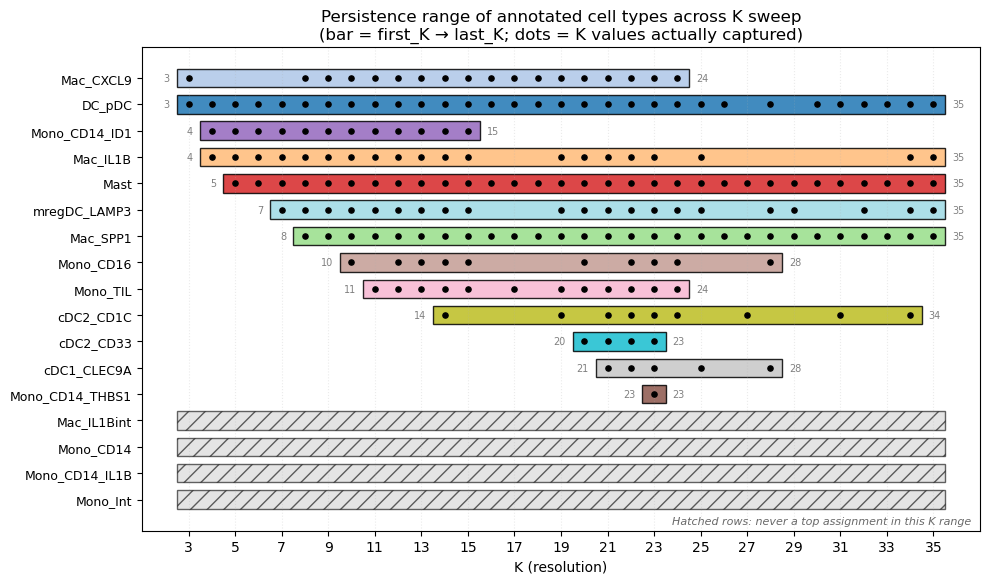

In [18]:
sorted_ems = emergence_df.sort_values('first_K', ascending=True).reset_index(drop=True)

n_rows = len(sorted_ems) + len(never_captured)
fig, ax = plt.subplots(figsize=(10, max(3, n_rows * 0.35)))

y_positions = []
for y, row in enumerate(sorted_ems.itertuples(index=False)):
    color = ct_colors.get(row.celltype, '#888888')
    ax.barh(y, row.last_K - row.first_K + 1, left=row.first_K - 0.5,
            color=color, edgecolor='black', height=0.7, alpha=0.85)
    present_ks = sorted(k_presence[row.celltype])
    ax.scatter(present_ks, [y] * len(present_ks),
               s=14, color='black', zorder=3)
    ax.text(row.first_K - 0.8, y, f'{row.first_K}',
            va='center', ha='right', fontsize=7, color='gray')
    ax.text(row.last_K + 0.8,  y, f'{row.last_K}',
            va='center', ha='left',  fontsize=7, color='gray')
    y_positions.append(y)

# Never-captured cell types shown as full-range hatched bars
offset = len(sorted_ems)
for i, ct in enumerate(never_captured):
    ax.barh(offset + i, K_MAX - K_MIN + 1, left=K_MIN - 0.5,
            color='lightgray', edgecolor='black', hatch='//',
            height=0.7, alpha=0.6)
    y_positions.append(offset + i)

ax.set_yticks(y_positions)
ax.set_yticklabels(list(sorted_ems['celltype']) + never_captured, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel('K (resolution)')
ax.set_title('Persistence range of annotated cell types across K sweep\n'
             '(bar = first_K → last_K; dots = K values actually captured)')
ax.set_xlim(K_MIN - 2, K_MAX + 2)
ax.set_xticks(range(K_MIN, K_MAX + 1, 2))
ax.grid(axis='x', alpha=0.25, linestyle=':')
ax.text(0.99, 0.01, 'Hatched rows: never a top assignment in this K range',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, style='italic', color='dimgray')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'emergence_span.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Ambiguity Rate and Program-per-CellType Trajectories

Two trajectories showing how the program landscape decomposes:

- **Ambiguity rate(K)** — fraction of GEPs at K whose top two cell types are too
  close in probability mass (per `AMBIGUITY_THRESHOLD`). Rising ambiguity with K
  means the landscape starts producing programs that multiple labels share equally.
- **Programs-per-cell-type(K)** — number of GEPs assigned to each cell type at
  each K. The shape of each curve tells you how that cell type decomposes: flat
  curves (stays at 1 GEP) = homogeneous; rising curves = heterogeneous within the
  annotation.

In [19]:
traj_records = []
for k in k_values:
    nes_k = all_nes[k]
    assignments = [assign_celltype(nes_k.loc[gep]) for gep in nes_k.index]
    n_total = len(assignments)
    n_amb     = sum(1 for ct in assignments if ct == 'Ambiguous/Mixed')
    n_family  = sum(1 for ct in assignments if is_family_label(ct))
    n_specific = n_total - n_amb - n_family
    unique_cts = set(assignments) - {'Ambiguous/Mixed'} - {c for c in assignments if is_family_label(c)}
    traj_records.append({
        'K': k,
        'n_total_GEPs': n_total,
        'n_ambiguous': n_amb,
        'n_family_level': n_family,
        'n_celltype_specific': n_specific,
        'ambiguity_rate':      n_amb     / n_total if n_total else 0.0,
        'family_level_rate':   n_family  / n_total if n_total else 0.0,
        'celltype_specific_rate': n_specific / n_total if n_total else 0.0,
        'n_unique_celltypes_covered': len(unique_cts),
    })
traj_df = pd.DataFrame(traj_records)

ppc_records = []
for k in k_values:
    nes_k = all_nes[k]
    cts = [assign_celltype(nes_k.loc[gep]) for gep in nes_k.index]
    for ct, n in Counter(cts).items():
        ppc_records.append({'K': k, 'celltype': ct, 'n_GEPs': n})
ppc_df = pd.DataFrame(ppc_records)
ppc_pivot = (ppc_df.pivot_table(index='K', columns='celltype',
                                values='n_GEPs', fill_value=0)
             .reindex(k_values, fill_value=0))

traj_df.to_csv(os.path.join(OUTPUT_DIR, 'landscape_trajectories.csv'), index=False)
ppc_pivot.to_csv(os.path.join(OUTPUT_DIR, 'program_per_celltype_trajectory.csv'))

print("Landscape trajectory summary:")
print(traj_df.to_string(index=False))
if traj_df['n_family_level'].sum() > 0:
    print(f"\nFamily-level resolution recovered {int(traj_df['n_family_level'].sum())} "
          f"GEPs that would otherwise be labeled Ambiguous/Mixed.")

Landscape trajectory summary:
 K  n_total_GEPs  n_ambiguous  n_family_level  n_celltype_specific  ambiguity_rate  family_level_rate  celltype_specific_rate  n_unique_celltypes_covered
 3             3            1               0                    2        0.333333           0.000000                0.666667                           2
 4             4            1               0                    3        0.250000           0.000000                0.750000                           3
 5             5            1               0                    4        0.200000           0.000000                0.800000                           4
 6             6            0               2                    4        0.000000           0.333333                0.666667                           4
 7             7            0               2                    5        0.000000           0.285714                0.714286                           5
 8             8            0               1 

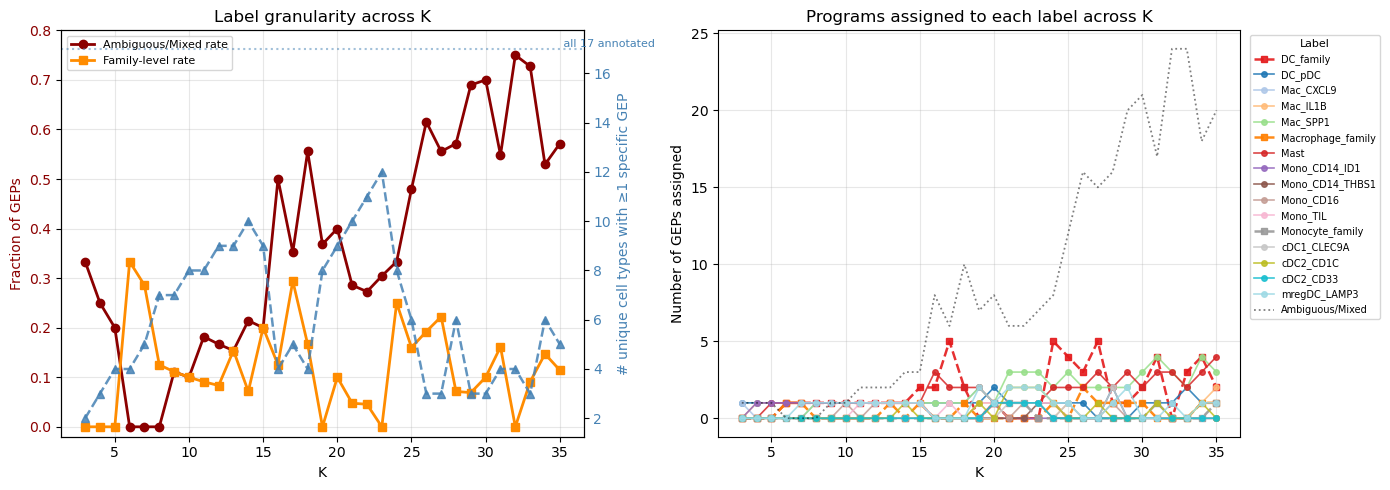

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: ambiguity / family-level / coverage across K ───────────
ax = axes[0]
ax.plot(traj_df['K'], traj_df['ambiguity_rate'], 'o-',
        color='darkred', lw=2, markersize=6, label='Ambiguous/Mixed rate')
if traj_df['n_family_level'].sum() > 0:
    ax.plot(traj_df['K'], traj_df['family_level_rate'], 's-',
            color='darkorange', lw=2, markersize=6,
            label='Family-level rate')
ax.set_xlabel('K')
ax.set_ylabel('Fraction of GEPs', color='darkred')
ax.tick_params(axis='y', labelcolor='darkred')
max_rate = max(0.5,
               traj_df['ambiguity_rate'].max() + 0.05,
               traj_df['family_level_rate'].max() + 0.05)
ax.set_ylim(-0.02, max_rate)
ax.grid(alpha=0.3)
ax.set_title('Label granularity across K')
ax.legend(loc='upper left', fontsize=8)

ax2 = ax.twinx()
ax2.plot(traj_df['K'], traj_df['n_unique_celltypes_covered'], '^--',
         color='steelblue', lw=1.8, markersize=6, alpha=0.85,
         label='Unique cell types covered')
ax2.set_ylabel('# unique cell types with ≥1 specific GEP',
               color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.axhline(len(annotated_cts), color='steelblue', ls=':', alpha=0.5)
ax2.text(k_values[-1], len(annotated_cts), f' all {len(annotated_cts)} annotated',
         color='steelblue', va='bottom', fontsize=8)

# ── Right: program-per-cell-type trajectories ───────────────
ax = axes[1]
for ct in ppc_pivot.columns:
    if ct == 'Ambiguous/Mixed':
        continue
    if is_family_label(ct):
        # Family labels: thicker, dashed, to stand out
        ax.plot(ppc_pivot.index, ppc_pivot[ct], 's--',
                color=ct_colors.get(ct, '#888888'), lw=1.8, markersize=5,
                label=ct, alpha=0.9)
    else:
        ax.plot(ppc_pivot.index, ppc_pivot[ct], 'o-',
                color=ct_colors.get(ct, '#888888'), lw=1.2, markersize=4,
                label=ct, alpha=0.85)
# Ambiguous as dashed black
if 'Ambiguous/Mixed' in ppc_pivot.columns:
    ax.plot(ppc_pivot.index, ppc_pivot['Ambiguous/Mixed'], ':',
            color='black', lw=1.3, alpha=0.5, label='Ambiguous/Mixed')
ax.set_xlabel('K')
ax.set_ylabel('Number of GEPs assigned')
ax.set_title('Programs assigned to each label across K')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7,
          title='Label', title_fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'landscape_trajectories.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 12. Annotation Granularity Diagnostics

Two statistics addressing whether the annotated cell types are
**too granular** (redundant labels that should merge) or form a coherent
family hierarchy:

- **12.1 Between-cell-type redundancy matrix** — for each K, Pearson correlation
  between NES columns (cell types) across all GEPs. Aggregated across K by median.
  High correlation = two labels fire on the same programs → MERGE candidate.
- **12.2 Family coherence diagnostic** — if `CELLTYPE_FAMILIES` is defined,
  partition the pairs from 12.1 into within-family and between-family pairs.
  A well-defined family hierarchy shows high within-family R and low between-family R.

Together these flag label pairs that are empirically redundant and check that
any hand-crafted family grouping matches the program structure in the data.


### 12.1 Between-cell-type Redundancy Matrix

In [21]:
all_cts_sorted = sorted(set().union(*[df.columns for df in all_nes.values()]))

per_k_corr = {}
for k in k_values:
    nes = all_nes[k].astype(float)
    if nes.shape[0] >= 3:                   # need ≥3 GEPs for meaningful correlation
        per_k_corr[k] = nes.corr(method='pearson')

# ── Median aggregation across K ─────────────────────────────────────
median_corr = pd.DataFrame(index=all_cts_sorted, columns=all_cts_sorted,
                           dtype=float)
for A in all_cts_sorted:
    for B in all_cts_sorted:
        vals = [c.loc[A, B] for c in per_k_corr.values()
                if A in c.index and B in c.columns
                and not np.isnan(c.loc[A, B])]
        if vals:
            median_corr.loc[A, B] = np.median(vals)

# Diagonal = 1 (self-correlation)
for ct in median_corr.index:
    median_corr.at[ct, ct] = 1.0
# Drop cell types that never co-appear (all-NaN row/col)
median_corr = (median_corr.dropna(how='all')
                          .dropna(axis=1, how='all')
                          .fillna(0))

median_corr.to_csv(os.path.join(OUTPUT_DIR, 'celltype_redundancy_matrix.csv'))
print(f"Redundancy matrix shape: {median_corr.shape}")
print(f"Number of K values contributing: {len(per_k_corr)}")


Redundancy matrix shape: (17, 17)
Number of K values contributing: 33


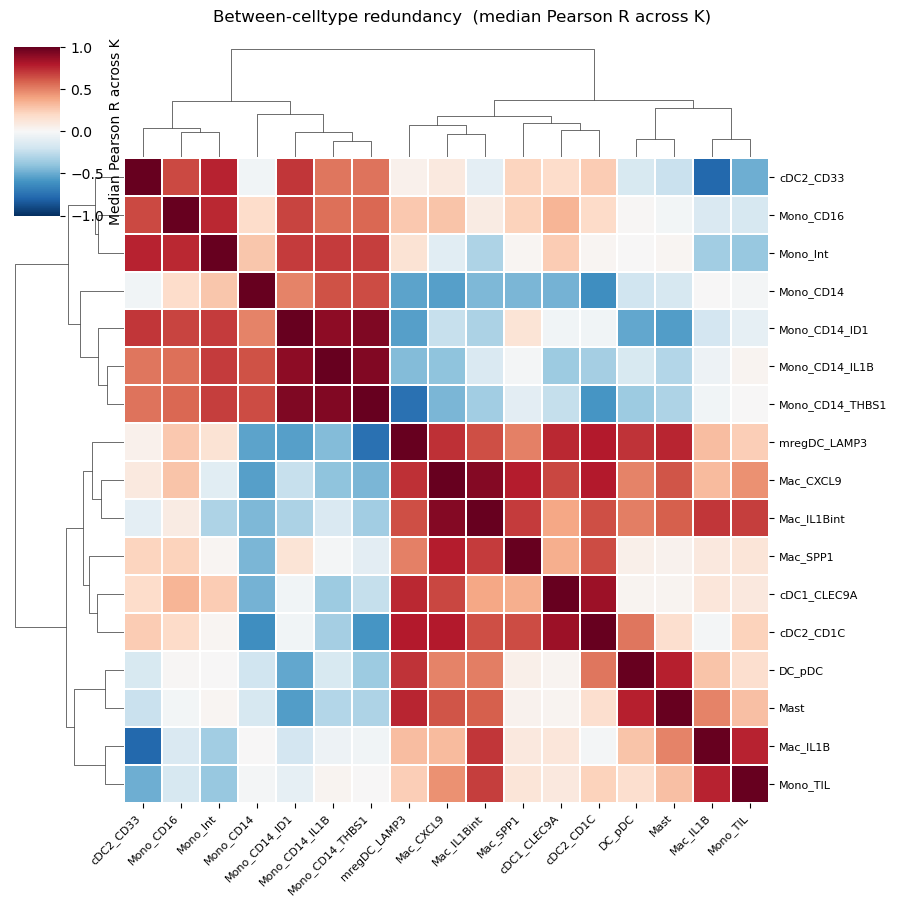

In [22]:
g = sns.clustermap(
    median_corr,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    method='average', metric='euclidean',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Median Pearson R across K'},
    figsize=(max(8, len(median_corr) * 0.55),
             max(8, len(median_corr) * 0.55)),
    dendrogram_ratio=0.15,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xmajorticklabels(), rotation=45, ha='right', fontsize=8)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_ymajorticklabels(), rotation=0, fontsize=8)
g.fig.suptitle('Between-celltype redundancy  (median Pearson R across K)',
               y=1.02, fontsize=12)
plt.savefig(os.path.join(OUTPUT_DIR, 'celltype_redundancy_clustermap.png'),
            dpi=150, bbox_inches='tight')
plt.show()


In [23]:
# Ranked MERGE candidates (upper triangle only, excluding diagonal)
pairs = []
cts_in_matrix = list(median_corr.index)
for i, A in enumerate(cts_in_matrix):
    for B in cts_in_matrix[i + 1:]:
        # Also record inter-quartile range across K as a stability measure
        vals = [c.loc[A, B] for c in per_k_corr.values()
                if A in c.index and B in c.columns
                and not np.isnan(c.loc[A, B])]
        pairs.append({
            'celltype_A': A,
            'celltype_B': B,
            'median_R_across_K': round(np.median(vals), 4) if vals else np.nan,
            'IQR_R_across_K':    round(np.subtract(*np.percentile(vals, [75, 25])), 4)
                                 if len(vals) >= 2 else np.nan,
            'n_K_contributing':  len(vals),
        })

merge_candidates = (pd.DataFrame(pairs)
                    .sort_values('median_R_across_K', ascending=False)
                    .reset_index(drop=True))
merge_candidates.to_csv(os.path.join(OUTPUT_DIR, 'merge_candidates.csv'),
                        index=False)

print("Top 15 MERGE candidates (highest median between-cell-type correlation):")
print(merge_candidates.head(15).to_string(index=False))
print("\nBottom 5 (most separable pairs, for reference):")
print(merge_candidates.tail(5).to_string(index=False))


Top 15 MERGE candidates (highest median between-cell-type correlation):
    celltype_A      celltype_B  median_R_across_K  IQR_R_across_K  n_K_contributing
 Mono_CD14_ID1 Mono_CD14_THBS1             0.9299          0.3534                33
Mono_CD14_IL1B Mono_CD14_THBS1             0.9290          0.1642                33
     Mac_CXCL9     Mac_IL1Bint             0.9195          0.2206                33
 Mono_CD14_ID1  Mono_CD14_IL1B             0.8936          0.1264                33
   cDC1_CLEC9A       cDC2_CD1C             0.8552          0.5857                33
     Mac_CXCL9       cDC2_CD1C             0.7947          0.2968                33
     cDC2_CD1C    mregDC_LAMP3             0.7893          0.4546                33
     Mac_CXCL9        Mac_SPP1             0.7845          0.5518                33
        DC_pDC            Mast             0.7763          0.8125                33
      Mono_Int       cDC2_CD33             0.7685          0.6085                33
    

### 12.2 Family Coherence Diagnostic

If `CELLTYPE_FAMILIES` is defined, the between-celltype redundancy matrix from
§12.1 can be partitioned into **within-family pairs** (two cell types in the
same family) and **between-family pairs** (two cell types in different families).

A well-defined family hierarchy should show:

- **High within-family median R** — members of the same family have similar
  NES profiles (they share programs).
- **Low between-family median R** — members of different families have
  dissimilar NES profiles.

If a particular family shows *low* within-family R, its members may not form a
coherent biological group. If a particular family *pair* shows *high*
between-family R, those two families may need to be merged, or one of them has
a member that really belongs in the other.

This cell is skipped entirely when `CELLTYPE_FAMILIES is None`.

In [24]:
if CELLTYPE_FAMILIES is None:
    print("CELLTYPE_FAMILIES is None — skipping family coherence diagnostic.")
    family_pair_df = None
    within_family_df = None
    between_family_df = None
else:
    ct_to_family = _build_ct_to_family(CELLTYPE_FAMILIES)

    # Tag every pair in merge_candidates with within/between family status
    mc = merge_candidates.copy()
    mc["family_A"] = mc["celltype_A"].map(ct_to_family)
    mc["family_B"] = mc["celltype_B"].map(ct_to_family)

    def _classify(row):
        if pd.isna(row["family_A"]) or pd.isna(row["family_B"]):
            return "unassigned"    # cell type not in any family (shouldn't happen for your dataset)
        if row["family_A"] == row["family_B"]:
            return "within"
        return "between"

    mc["pair_type"] = mc.apply(_classify, axis=1)

    # Normalized family-pair label, alphabetized so "DC ↔ Monocyte" == "Monocyte ↔ DC"
    def _pair_label(row):
        fa, fb = row["family_A"], row["family_B"]
        if pd.isna(fa) or pd.isna(fb):
            return None
        a, b = sorted([fa, fb])
        return f"{a} ↔ {b}" if a != b else a

    mc["family_pair"] = mc.apply(_pair_label, axis=1)

    family_pair_df = mc.sort_values("median_R_across_K", ascending=False)
    family_pair_df.to_csv(
        os.path.join(OUTPUT_DIR, "merge_candidates_with_family.csv"), index=False)

    # ── Within-family summary: how coherent is each family? ──────────
    within = mc[mc["pair_type"] == "within"]
    if len(within) > 0:
        within_family_df = (within.groupby("family_A")
                            .agg(n_pairs=("median_R_across_K", "count"),
                                 median_within_R=("median_R_across_K", "median"),
                                 mean_within_R  =("median_R_across_K", "mean"),
                                 min_within_R   =("median_R_across_K", "min"),
                                 max_within_R   =("median_R_across_K", "max"))
                            .round(3)
                            .sort_values("median_within_R", ascending=False))
        within_family_df.index.name = "family"
        within_family_df.to_csv(
            os.path.join(OUTPUT_DIR, "family_coherence_within.csv"))
    else:
        within_family_df = pd.DataFrame()

    # ── Between-family summary: which pairs of families look similar? ──
    between = mc[mc["pair_type"] == "between"]
    if len(between) > 0:
        between_family_df = (between.groupby("family_pair")
                             .agg(n_pairs=("median_R_across_K", "count"),
                                  median_between_R=("median_R_across_K", "median"),
                                  mean_between_R  =("median_R_across_K", "mean"),
                                  min_between_R   =("median_R_across_K", "min"),
                                  max_between_R   =("median_R_across_K", "max"))
                             .round(3)
                             .sort_values("median_between_R", ascending=False))
        between_family_df.to_csv(
            os.path.join(OUTPUT_DIR, "family_coherence_between.csv"))
    else:
        between_family_df = pd.DataFrame()

    print("=" * 78)
    print("WITHIN-FAMILY coherence  (higher = family members share programs):")
    print("=" * 78)
    if len(within_family_df) > 0:
        print(within_family_df.to_string())
    else:
        print("  (no within-family pairs — all families are singletons)")

    print()
    print("=" * 78)
    print("BETWEEN-FAMILY overlap  (higher = families may not be cleanly separated):")
    print("=" * 78)
    if len(between_family_df) > 0:
        print(between_family_df.to_string())

    # Quick sanity signal: compare medians
    if len(within) > 0 and len(between) > 0:
        med_within  = within["median_R_across_K"].median()
        med_between = between["median_R_across_K"].median()
        gap = med_within - med_between
        print()
        print(f"Overall median within-family  R = {med_within:+.3f}")
        print(f"Overall median between-family R = {med_between:+.3f}")
        print(f"Gap (within − between)         = {gap:+.3f}")
        if gap > 0.2:
            print("  → Families are cleanly separated from one another.")
        elif gap > 0.05:
            print("  → Modest separation; some inter-family overlap.")
        else:
            print("  → WARNING: within ≈ between. Family definitions may not match "
                  "the empirical program structure.")

WITHIN-FAMILY coherence  (higher = family members share programs):
            n_pairs  median_within_R  mean_within_R  min_within_R  max_within_R
family                                                                         
Macrophage        6            0.708          0.590         0.103         0.920
Monocyte         21            0.571          0.429        -0.380         0.930
DC               10            0.395          0.401        -0.159         0.855

BETWEEN-FAMILY overlap  (higher = families may not be cleanly separated):
                       n_pairs  median_between_R  mean_between_R  min_between_R  max_between_R
family_pair                                                                                   
Macrophage ↔ Mast            4             0.547           0.442          0.047          0.626
DC ↔ Macrophage             20             0.376           0.329         -0.786          0.795
DC ↔ Mast                    5             0.167           0.302         -0.22

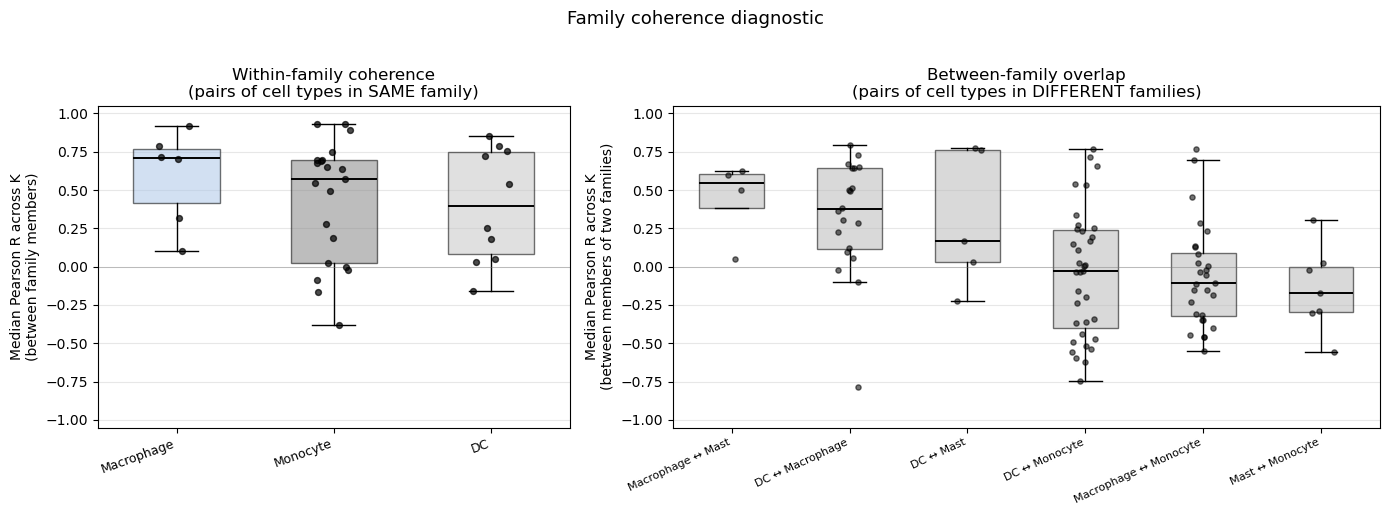

Saved → combined-hnc_k3-35_corr-tree_kl-divergence/family_coherence.png


In [25]:
if CELLTYPE_FAMILIES is None or family_pair_df is None:
    pass  # diagnostic was skipped
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={"width_ratios": [1.2, 1.8]})

    # ── Left: within-family boxplot (one box per family) ──────────
    ax = axes[0]
    within = family_pair_df[family_pair_df["pair_type"] == "within"]
    if len(within) > 0 and len(within_family_df) > 0:
        fam_order = within_family_df.index.tolist()
        data = [within[within["family_A"] == f]["median_R_across_K"].values
                for f in fam_order]
        bp = ax.boxplot(data, positions=range(len(fam_order)), widths=0.55,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", lw=1.4))
        # Use the ct_colors of one of the family's members for tinting the box
        for patch, fam in zip(bp["boxes"], fam_order):
            members = CELLTYPE_FAMILIES[fam]
            # Grab the first member's color; fall back to gray
            col = ct_colors.get(members[0], "#888888")
            patch.set_facecolor(col)
            patch.set_alpha(0.55)

        # Overlay raw points
        for i, f in enumerate(fam_order):
            vals = within[within["family_A"] == f]["median_R_across_K"].values
            if len(vals) == 0:
                continue
            jit = np.random.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jit, vals,
                       c="black", s=18, alpha=0.7, zorder=3)

        ax.set_xticks(range(len(fam_order)))
        ax.set_xticklabels(fam_order, rotation=20, ha="right", fontsize=9)
        ax.set_ylabel("Median Pearson R across K\n(between family members)")
        ax.set_title("Within-family coherence\n(pairs of cell types in SAME family)")
    else:
        ax.text(0.5, 0.5, "No within-family pairs\n(all singletons)",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("Within-family coherence")

    ax.axhline(0, color="gray", lw=0.6, alpha=0.5)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(axis="y", alpha=0.3)

    # ── Right: between-family boxplot (one box per family pair) ──────
    ax = axes[1]
    between = family_pair_df[family_pair_df["pair_type"] == "between"]
    if len(between) > 0 and len(between_family_df) > 0:
        pair_order = between_family_df.index.tolist()
        data = [between[between["family_pair"] == p]["median_R_across_K"].values
                for p in pair_order]
        bp = ax.boxplot(data, positions=range(len(pair_order)), widths=0.55,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", lw=1.4))
        for patch in bp["boxes"]:
            patch.set_facecolor("#bbbbbb")
            patch.set_alpha(0.55)

        for i, p in enumerate(pair_order):
            vals = between[between["family_pair"] == p]["median_R_across_K"].values
            if len(vals) == 0:
                continue
            jit = np.random.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jit, vals,
                       c="black", s=14, alpha=0.55, zorder=3)

        ax.set_xticks(range(len(pair_order)))
        ax.set_xticklabels(pair_order, rotation=25, ha="right", fontsize=8)
        ax.set_ylabel("Median Pearson R across K\n(between members of two families)")
        ax.set_title("Between-family overlap\n(pairs of cell types in DIFFERENT families)")
    else:
        ax.text(0.5, 0.5, "No between-family pairs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("Between-family overlap")

    ax.axhline(0, color="gray", lw=0.6, alpha=0.5)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Family coherence diagnostic", fontsize=13, y=1.02)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "family_coherence.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

## 13. Joint Granularity Summary

A single table combining each cell type's emergence K (§11.2), best-achieved
lineage persistence (§11.1), and strongest MERGE partner (§12.1). This is
the condensed annotation-diagnostic table.


In [26]:
summary_rows = []
best_persistence = (lineage_df[lineage_df['n_nodes'] >= 2]
                    .groupby('dominant_celltype')['consecutive_span'].max()
                    .to_dict())

for ct in sorted(annotated_cts):
    # emergence
    first_K = emergence.get(ct, None)
    # best persistence
    best_pers = best_persistence.get(ct, None)
    # strongest merge partner
    partner_rows = merge_candidates[
        (merge_candidates['celltype_A'] == ct) |
        (merge_candidates['celltype_B'] == ct)
    ].head(1)
    if len(partner_rows) > 0:
        pr = partner_rows.iloc[0]
        other = pr['celltype_B'] if pr['celltype_A'] == ct else pr['celltype_A']
        top_partner = other
        top_partner_R = pr['median_R_across_K']
    else:
        top_partner = None
        top_partner_R = np.nan

    summary_rows.append({
        'celltype': ct,
        'emerges_at_K': first_K,
        'best_consecutive_persistence': best_pers,
        'top_merge_partner': top_partner,
        'top_merge_partner_R': (round(top_partner_R, 4)
                                if not pd.isna(top_partner_R) else np.nan),
    })

joint_summary = pd.DataFrame(summary_rows).sort_values(
    ['emerges_at_K', 'celltype'], na_position='last')
joint_summary.to_csv(os.path.join(OUTPUT_DIR, 'joint_granularity_summary.csv'),
                     index=False)

print("Joint granularity summary (per annotated cell type):")
print("=" * 90)
print(joint_summary.to_string(index=False))
print("\nInterpretation:")
print("  - High top_merge_partner_R         → merge candidate with the listed partner")
print("  - High best_consecutive_persistence → robust, stable program")


Joint granularity summary (per annotated cell type):
       celltype  emerges_at_K  best_consecutive_persistence top_merge_partner  top_merge_partner_R
         DC_pDC           3.0                           NaN              Mast               0.7763
      Mac_CXCL9           3.0                           NaN       Mac_IL1Bint               0.9195
       Mac_IL1B           4.0                           NaN          Mono_TIL               0.7663
  Mono_CD14_ID1           4.0                           7.0   Mono_CD14_THBS1               0.9299
           Mast           5.0                           NaN            DC_pDC               0.7763
   mregDC_LAMP3           7.0                           NaN         cDC2_CD1C               0.7893
       Mac_SPP1           8.0                           NaN         Mac_CXCL9               0.7845
      Mono_CD16          10.0                           NaN          Mono_Int               0.7512
       Mono_TIL          11.0                           